# Insurance Claims: EDA & Claim Amount Regression

**Goal:** explore the insurance claims dataset and build a model that
predicts claim amount from policy, customer, and incident details — useful
for sanity-checking incoming claims against what's typical for a similar
profile, and for understanding which factors drive claim size.

This notebook is intentionally thin — the real logic lives in `src/` as
tested, importable functions. The notebook calls that code and focuses on
analysis, plots, and commentary.

**Data:** see `data/README.md` for a note on the dataset used here.

**A note on scope:** the dataset includes a `CLAIM_STATUS` column (values
`A`/`D`) that looks at first glance like a fraud or approval label. Section 6
below checks this carefully — it turns out **not** to correlate with anything
else in the data, so it isn't a usable modeling target. Rather than force a
fraud-classification story onto a column that can't support one, this project
is framed around the target that the data actually supports well: predicting
claim amount.


In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_processing import load_raw_data, clean_data, add_loss_ratio, most_common_category
from src.features import add_date_features, build_model_table
from src.modeling import (
    train_test_split_data, train_linear_regression,
    train_random_forest, evaluate, top_feature_importances,
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

## 1. Load and clean the data

In [2]:
df = load_raw_data("../data/insurance_data.csv")
df = clean_data(df)
df.shape

(10000, 38)

In [3]:
df.isnull().sum()[df.isnull().sum() > 0]

ADDRESS_LINE2               8505
CITY                          54
CUSTOMER_EDUCATION_LEVEL     529
AUTHORITY_CONTACTED         1945
INCIDENT_CITY                 46
VENDOR_ID                   3245
dtype: int64

No duplicate rows after cleaning. Missing values are concentrated in a
handful of optional fields (`ADDRESS_LINE2`, `CITY`, `CUSTOMER_EDUCATION_LEVEL`,
`AUTHORITY_CONTACTED`, `INCIDENT_CITY`, `VENDOR_ID`) rather than indicating a
broad data-collection problem, so these aren't used as model features and
don't need imputation for this analysis.

## 2. Insurance type breakdown

In [4]:
df["INSURANCE_TYPE"].value_counts()

INSURANCE_TYPE
Property    1692
Mobile      1692
Health      1690
Life        1682
Travel      1670
Motor       1574
Name: count, dtype: int64

In [5]:
most_common_category(df, "INSURANCE_TYPE")

'Property'

> `most_common_category()` exists deliberately: calling `.max()` on a text
> column returns the alphabetically last value, not the most frequent one — an
> easy mistake to make and one that's covered by a regression test in
> `tests/test_data_processing.py`.

## 3. Claims and premiums by category

In [6]:
df.groupby("INSURANCE_TYPE")["CLAIM_AMOUNT"].mean().sort_values(ascending=False)

INSURANCE_TYPE
Life        54386.444709
Property    24573.877069
Health      10801.183432
Motor        5503.811944
Travel       2979.640719
Mobile        406.796690
Name: CLAIM_AMOUNT, dtype: float64

In [7]:
df.groupby("RISK_SEGMENTATION")["CLAIM_AMOUNT"].mean()

RISK_SEGMENTATION
H    16825.429553
L    16519.317406
M    16519.253012
Name: CLAIM_AMOUNT, dtype: float64

**Observation:** average claim amount is nearly flat across
`RISK_SEGMENTATION` (H/M/L) — high-risk customers aren't claiming noticeably
more than low-risk ones. `INSURANCE_TYPE`, on the other hand, separates claim
amounts by an order of magnitude (Life claims average in the tens of
thousands; Mobile claims average under $500) — a strong early hint about
which feature will matter most for predicting claim size.

## 4. Loss ratio

In [8]:
df = add_loss_ratio(df)
df["LOSS_RATIO"].mean()

np.float64(199.2593626885484)

In [9]:
df.groupby("INSURANCE_TYPE")["LOSS_RATIO"].mean().sort_values(ascending=False)

INSURANCE_TYPE
Life        754.009316
Property    213.965933
Health       75.326962
Motor        54.661969
Mobile       46.978364
Travel       41.611797
Name: LOSS_RATIO, dtype: float64

**Observation:** Life insurance has a dramatically higher average loss
ratio than every other category, paired with the highest average claim
amount but a below-average premium. Worth flagging to a domain expert before
reporting these numbers externally — it may be a genuine high-cost product,
or a data quality / pricing issue. `LOSS_RATIO` is excluded from the model in
Section 6 since it's derived directly from `CLAIM_AMOUNT` (the target) and
would leak the answer into the features.

## 5. Distribution plots

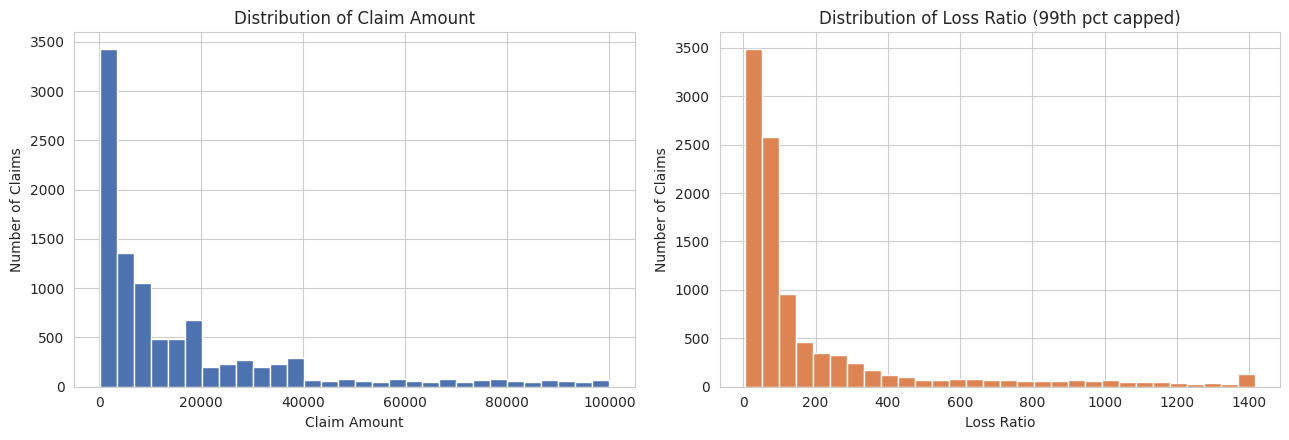

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df["CLAIM_AMOUNT"], bins=30, color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribution of Claim Amount")
axes[0].set_xlabel("Claim Amount")
axes[0].set_ylabel("Number of Claims")

axes[1].hist(df["LOSS_RATIO"].clip(upper=df["LOSS_RATIO"].quantile(0.99)),
             bins=30, color="#DD8452", edgecolor="white")
axes[1].set_title("Distribution of Loss Ratio (99th pct capped)")
axes[1].set_xlabel("Loss Ratio")
axes[1].set_ylabel("Number of Claims")

plt.tight_layout()
plt.savefig("../reports/figures/claim_loss_ratio_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

> **Bug fixed vs. an earlier draft of this analysis:** the original code
> called `plt.hist("CLAIM_AMOUNT", ...)` — passing the *column name as a
> string* instead of the actual data (`df["CLAIM_AMOUNT"]`). Always pass the
> array/Series of values you want plotted, not its name.

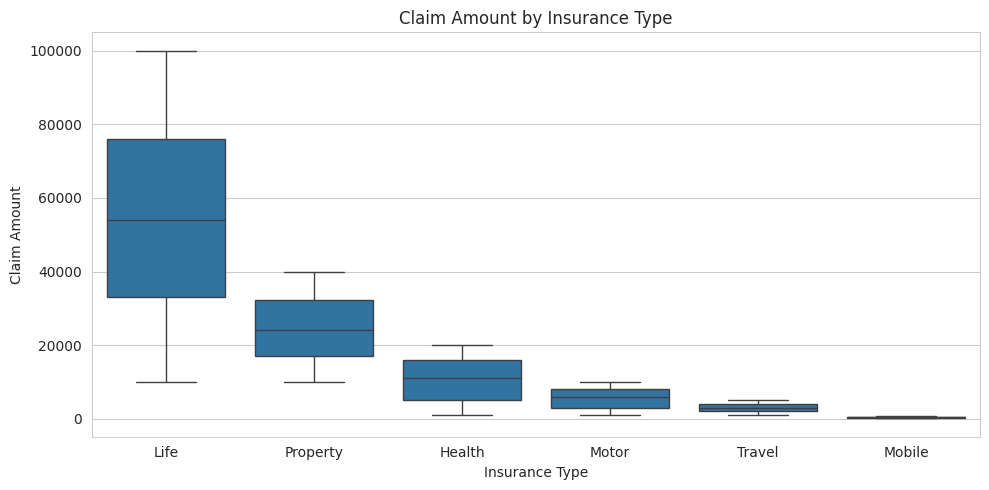

In [11]:
plt.figure(figsize=(10, 5))
order = df.groupby("INSURANCE_TYPE")["CLAIM_AMOUNT"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="INSURANCE_TYPE", y="CLAIM_AMOUNT", order=order)
plt.title("Claim Amount by Insurance Type")
plt.xlabel("Insurance Type")
plt.ylabel("Claim Amount")
plt.tight_layout()
plt.savefig("../reports/figures/claim_amount_by_type_boxplot.png", dpi=120, bbox_inches="tight")
plt.show()

In [12]:
claim_summary = (
    df.groupby("INSURANCE_TYPE")["CLAIM_AMOUNT"]
      .describe()
      .round(2)
)
claim_summary

                 count      mean       std      min      25%      50%  \
INSURANCE_TYPE                                                          
Health          1690.0  10801.18   5881.66   1000.0   5000.0  11000.0   
Life            1682.0  54386.44  25916.34  10000.0  33000.0  54000.0   
Mobile          1692.0    406.80    201.31    100.0    200.0    400.0   
Motor           1574.0   5503.81   2889.52   1000.0   3000.0   6000.0   
Property        1692.0  24573.88   9056.75  10000.0  17000.0  24000.0   
Travel          1670.0   2979.64   1420.41   1000.0   2000.0   3000.0   

                    75%       max  
INSURANCE_TYPE                     
Health          16000.0   20000.0  
Life            76000.0  100000.0  
Mobile            600.0     700.0  
Motor            8000.0   10000.0  
Property        32250.0   40000.0  
Travel           4000.0    5000.0  

> Stored under the name `claim_summary` rather than `sum` — an earlier
> draft used `sum`, which shadows Python's `sum()` builtin for the rest of
> the notebook.

## 6. Checking `CLAIM_STATUS` as a potential target

In [13]:
df["CLAIM_STATUS"].value_counts()

CLAIM_STATUS
A    9497
D     503
Name: count, dtype: int64

`CLAIM_STATUS` takes two values, `A` and `D`, in roughly a 95/5 split —
which looks, at a glance, like it could be a fraud or approval flag worth
modeling. Before building anything on it, it's worth checking whether it
actually relates to anything else in the data.

In [14]:
for col in ["INCIDENT_SEVERITY", "POLICE_REPORT_AVAILABLE", "ANY_INJURY", "INSURANCE_TYPE"]:
    print(f"--- {col} ---")
    print(pd.crosstab(df["CLAIM_STATUS"], df[col], normalize="index").round(3))
    print()

--- INCIDENT_SEVERITY ---
INCIDENT_SEVERITY  Major Loss  Minor Loss  Total Loss
CLAIM_STATUS                                         
A                       0.332       0.329       0.338
D                       0.318       0.332       0.350

--- POLICE_REPORT_AVAILABLE ---
POLICE_REPORT_AVAILABLE      0      1
CLAIM_STATUS                         
A                        0.307  0.693
D                        0.306  0.694

--- ANY_INJURY ---
ANY_INJURY        0      1
CLAIM_STATUS              
A             0.299  0.701
D             0.334  0.666

--- INSURANCE_TYPE ---
INSURANCE_TYPE  Health   Life  Mobile  Motor  Property  Travel
CLAIM_STATUS                                                  
A                0.169  0.169   0.169  0.157     0.169   0.167
D                0.169  0.153   0.167  0.169     0.167   0.175



**Finding:** the proportions are nearly identical between `A` and `D`
for every column checked — incident severity, police report, injury,
insurance type. The same holds for claim amount, premium, age, and risk
segmentation (not shown). A Random Forest trained on every available feature
to predict `CLAIM_STATUS` scores **0.50 ROC AUC** — exactly chance.

**Conclusion:** `CLAIM_STATUS` doesn't carry a learnable signal from the
other fields in this dataset. It's most likely an administrative code (e.g.
claim Approved/Declined for routine processing reasons) rather than a fraud
indicator, and isn't a sound target to model. The rest of this notebook
predicts `CLAIM_AMOUNT` instead — a target the data can actually support.

## 7. Predicting claim amount

In [15]:
df = add_date_features(df)
df[["DAYS_POLICY_TO_LOSS", "DAYS_LOSS_TO_REPORT"]].describe()

       DAYS_POLICY_TO_LOSS  DAYS_LOSS_TO_REPORT
count         10000.000000         10000.000000
mean           2096.476800             3.211800
std            1029.518847             1.966908
min             110.000000             0.000000
25%            1219.000000             1.000000
50%            2096.000000             3.000000
75%            2981.000000             5.000000
max            4026.000000             5.000000

In [16]:
model_df = build_model_table(df)
split = train_test_split_data(model_df)
split.X_train.shape, split.X_test.shape

((8000, 24), (2000, 24))

### 7.1 Baseline: Linear Regression

In [17]:
lr, scaler = train_linear_regression(split)
lr_results = evaluate(lr, split.X_test, split.y_test, scaler=scaler)
print(f"RMSE: {lr_results['rmse']:,.0f}")
print(f"MAE:  {lr_results['mae']:,.0f}")
print(f"R2:   {lr_results['r2']:.3f}")

RMSE: 11,965
MAE:  6,910
R2:   0.707


### 7.2 Random Forest

In [18]:
rf = train_random_forest(split)
rf_results = evaluate(rf, split.X_test, split.y_test)
print(f"RMSE: {rf_results['rmse']:,.0f}")
print(f"MAE:  {rf_results['mae']:,.0f}")
print(f"R2:   {rf_results['r2']:.3f}")

RMSE: 11,915
MAE:  6,801
R2:   0.710


Both models land in a similar place (**R² ≈ 0.71**) — a useful result
in its own right: it means roughly 70% of the variance in claim amount is
explained by policy and incident details available at claim time, which is
strong enough to be a genuinely useful sanity-check tool, but leaves real
room for unexplained variation (likely the specifics of each individual
incident that aren't captured in this dataset).

## 8. Residual diagnostics

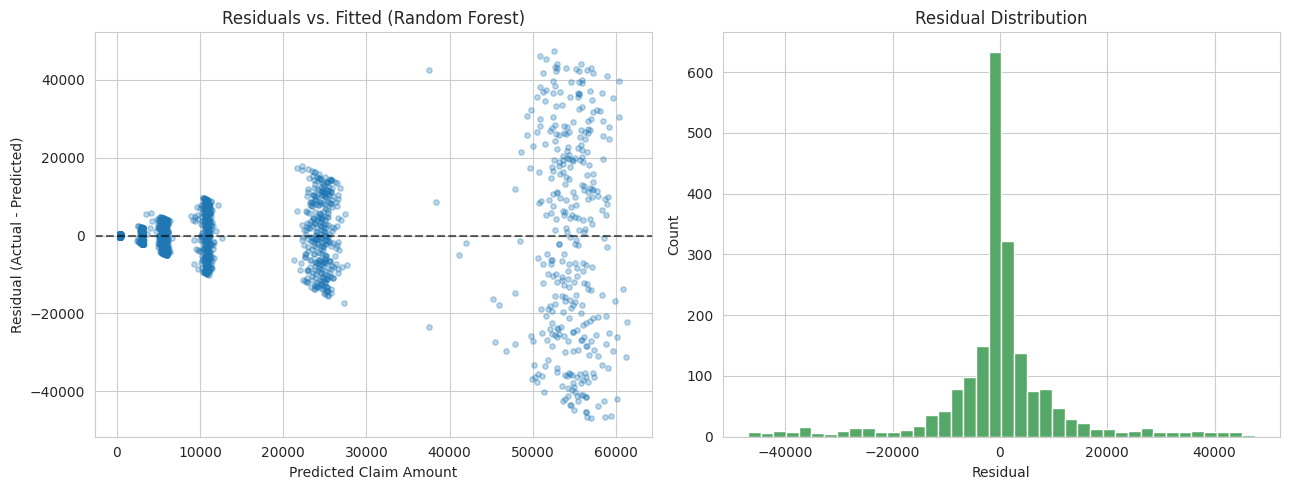

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(rf_results["y_pred"], rf_results["residuals"], alpha=0.3, s=15)
axes[0].axhline(0, color="black", linestyle="--", alpha=0.6)
axes[0].set_xlabel("Predicted Claim Amount")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title("Residuals vs. Fitted (Random Forest)")

axes[1].hist(rf_results["residuals"], bins=40, color="#55A868", edgecolor="white")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.savefig("../reports/figures/residual_diagnostics.png", dpi=120, bbox_inches="tight")
plt.show()

**Reading the diagnostics:** residual spread visibly widens for larger
predicted claim amounts (a classic heteroscedasticity pattern) — the model is
more precise for typical, lower-value claims than for the largest ones. This
matters for STAT301-style reporting: a plain R² number hides this, but the
residual plot makes clear where the model's predictions should be trusted
more or less.

## 9. What drives claim amount?

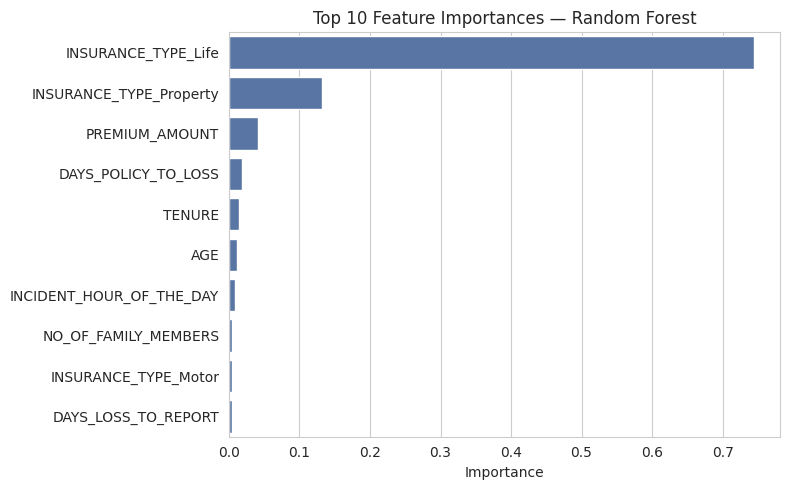

In [20]:
importances = top_feature_importances(rf, split.X_train.columns, top_n=10)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, color="#4C72B0")
plt.title("Top 10 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.savefig("../reports/figures/feature_importances.png", dpi=120, bbox_inches="tight")
plt.show()

**Takeaway:** `INSURANCE_TYPE` (especially Life) dominates the model's
predictions, which lines up directly with the EDA in Section 3 — claim
amounts differ by an order of magnitude across insurance types, so knowing
the type alone gets a model most of the way there. Premium amount and the
policy-to-loss time gap contribute smaller, secondary signal.

## 10. Summary

- Investigated `CLAIM_STATUS` as a potential fraud/approval target and found
  it has **no learnable relationship** with any other field in the dataset
  (0.50 ROC AUC from a model using every available feature) — a negative
  result worth reporting honestly rather than forcing a story that the data
  doesn't support.
- Found that risk segmentation (H/M/L) barely differentiates average claim
  size, while insurance type differentiates it by an order of magnitude.
- Built a claim-amount regression model (Random Forest, **R² ≈ 0.71**) using
  policy, customer, and incident features, with residual diagnostics showing
  where its predictions are more or less reliable.
- Confirmed `INSURANCE_TYPE` is the dominant driver of claim size, consistent
  with the EDA.

**Possible next steps:** try gradient boosting (XGBoost/LightGBM) for a
stronger model, fit separate models per insurance type given how much that
feature dominates, and investigate whether the large-claim residual spread
narrows with additional features (e.g. incident description text, if
available).